In [1]:
path="/Users/lorenzaimpicicche/Desktop/astrostatistics_bicoccs_2025/working/W20.h5"

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

In [3]:
f = h5py.File("W20.h5", "r")

In [4]:
print(list(f.keys()))

['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']


In [5]:
mtot=f["mtot"][:]
q=f["q"][:]
chi1x=f["chi1x"][:]
chi1y=f["chi1y"][:]
chi1z=f["chi1z"][:]
chi2x=f["chi2x"][:]
chi2y=f["chi2y"][:]
chi2z=f["chi2z"][:]
ra=f["ra"][:]
dec=f["dec"][:]
iota=f["iota"][:]
psi=f["psi"][:]
z=f["z"][:]
det=f["det"][:]

In [6]:
df= np.stack([mtot, q, chi1x, chi1y, chi1z, chi2x, chi2y, chi2z, ra, dec, iota, psi, z], axis=1 )

In [7]:
df=pd.DataFrame(df)
df.columns = ['mtot', 'q', 'chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'ra', 'dec', 'iota', 'psi', 'z']

In [8]:
df

,mtot,q,chi1x,chi1y,chi1z,chi2x,chi2y,chi2z,ra,dec,iota,psi,z
0,906.803562,0.624780,-0.307201,0.276165,-0.430760,-0.161114,-0.092334,-0.414647,-3.116784,-0.329671,1.809310,1.286031,2.139659
1,59.102112,0.986650,-0.734712,-0.498493,-0.298162,0.057532,-0.844992,0.014708,1.360291,0.526740,0.820820,0.934308,2.438707
2,44.602750,0.286199,-0.057831,-0.703796,-0.354512,-0.215538,0.016323,0.130543,0.079973,0.315799,2.008206,1.535520,1.869461
3,534.378032,0.538882,0.015260,-0.202467,-0.492768,-0.237033,-0.365363,-0.876192,-1.780558,0.432105,2.018398,3.064086,0.428061
4,573.821705,0.846310,-0.016731,0.007848,0.005007,0.147519,0.231879,0.086716,2.789289,-0.458711,2.037363,0.752211,0.772609
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19999995,47.173930,0.721899,-0.192062,-0.132125,0.099840,0.244232,-0.610395,0.205643,2.747641,0.227502,1.712124,0.458902,2.942686
19999996,319.515160,0.276340,-0.004265,-0.056190,-0.030455,0.080665,-0.263666,-0.028503,-3.010306,-0.289584,1.796748,2.011788,1.348554
19999997,536.491292,0.909982,-0.558253,-0.107589,0.065246,0.305706,-0.212490,-0.412048,-1.638381,-0.236878,0.894741,1.776291,0.826640
19999998,879.055152,0.287587,0.084775,-0.042762,0.017719,0.145657,0.474321,0.744677,2.211932,0.104063,1.102068,1.317251,3.125594


In [12]:
#Downsample
X_sampled, _, y_sampled, _ = train_test_split(df, det, train_size=1000, stratify=det, random_state=42)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sampled, y_sampled, test_size=0.2, random_state=42, stratify=y_sampled
)

In [15]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=0)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=0)

In [ ]:
y_prob = rf.predict_proba(X_test)[:, 1]
y_pred = rf.predict(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

Text(0, 0.5, 'True Positive Rate')

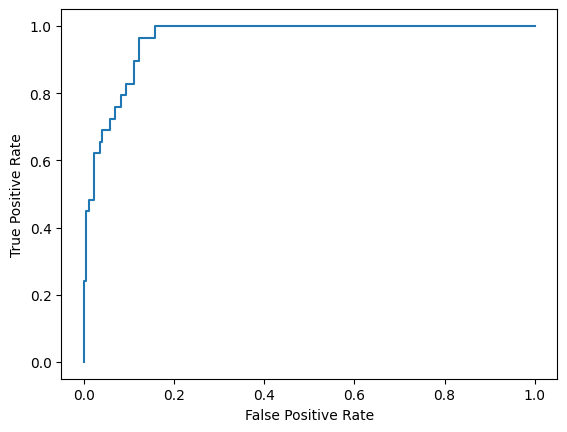

In [20]:
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")